### Carga datos

In [7]:
#Obtención de la data
from LHC import experiment_CMS
experiment_CMS(num_img=500, size=64, zip_name="CERN_dataset")

Dataset generado con 500 imágenes por clase.
Archivo comprimido: CERN_dataset.zip


In [3]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

def cargar_datos(zip_path="CERN_dataset.zip", carpeta_salida="CERN_datos"):
    #1. Proceso para descomprimir el archivo ZIP
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(carpeta_salida)
    X = []
    y = []
    #2. Recorrer las carpetas con las imagenes
    for clase in os.listdir(carpeta_salida):
        clase_path = os.path.join(carpeta_salida, clase)
        if os.path.isdir(clase_path):
            for img_name in tqdm(os.listdir(clase_path), desc=f"Cargando {clase}"):
                img_path = os.path.join(clase_path, img_name)

                # 3. Procedimiento para cargar imagenes en escala de grises
                img = Image.open(img_path).convert("L")
                X.append(np.array(img))
                y.append(clase)  # etiqueta = nombre de la carpeta

    X = np.array(X)
    return X, y

In [4]:
X, y = cargar_datos("CERN_dataset.zip")
print(f"Se cargaron {len(X)} imágenes.")
print(f"Clases encontradas: {set(y)}")
print("Dimensiones de las imágenes:", X.shape)

Cargando electron:   0%|          | 0/500 [00:00<?, ?it/s]

Cargando muon:   0%|          | 0/500 [00:00<?, ?it/s]

Cargando neutrino:   0%|          | 0/500 [00:00<?, ?it/s]

Cargando proton:   0%|          | 0/500 [00:00<?, ?it/s]

Cargando quark:   0%|          | 0/500 [00:00<?, ?it/s]

Cargando tau:   0%|          | 0/500 [00:00<?, ?it/s]

Se cargaron 3000 imágenes.
Clases encontradas: {'muon', 'quark', 'proton', 'tau', 'electron', 'neutrino'}
Dimensiones de las imágenes: (3000, 64, 64)


### Pre procesamiento datos

In [ ]:
# Pre-procesamiento para clasificación
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# 1. Etiquetar (codificar etiquetas)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print('Etiquetas codificadas:', set(y_encoded))

print('Shape original:', X.shape)
# 2. Aplanar imágenes
X_flat = X.reshape(X.shape[0], -1)
print('Shape aplanado:', X_flat.shape)

# 3. Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)
print('Shape escalado:', X_scaled.shape)

Etiquetas codificadas: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)}
Shape original: (3000, 64, 64)
Shape aplanado: (3000, 4096)
Shape escalado: (3000, 4096)
Shape escalado: (3000, 4096)
Shape PCA: (3000, 50)
Shape PCA: (3000, 50)


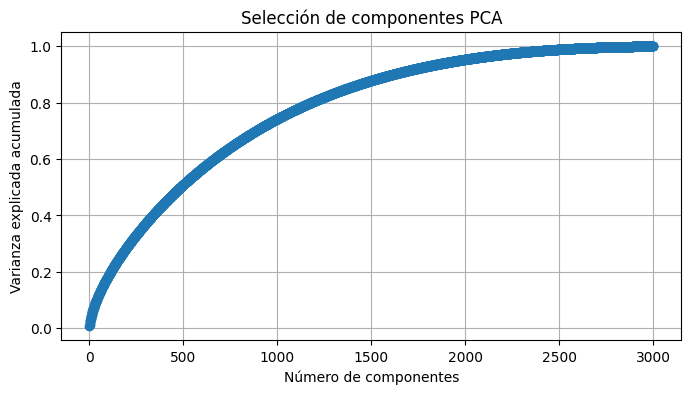

Número óptimo de componentes PCA para >=95% varianza: 1970
Shape PCA óptimo: (3000, 1970)


In [6]:
# Selección óptima de componentes PCA según varianza explicada acumulada
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Ajustar PCA sin limitar componentes
pca_full = PCA()
pca_full.fit(X_scaled)

# Calcular varianza explicada acumulada
cumsum = np.cumsum(pca_full.explained_variance_ratio_)

# Graficar curva de varianza explicada
plt.figure(figsize=(8,4))
plt.plot(cumsum, marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Selección de componentes PCA')
plt.grid(True)
plt.show()

# Elegir el número de componentes para retener >=95% de la varianza
n_opt = np.argmax(cumsum >= 0.95) + 1
print(f'Número óptimo de componentes PCA para >=95% varianza:', n_opt)

# Aplicar PCA con ese número de componentes
pca_opt = PCA(n_components=n_opt)
X_pca_opt = pca_opt.fit_transform(X_scaled)
print('Shape PCA óptimo:', X_pca_opt.shape)

In [8]:
# 4. Reducción de dimensionalidad (opcional, por ejemplo a 50 componentes)
pca = PCA(n_components=1970)
X_pca = pca.fit_transform(X_scaled)
print('Shape PCA:', X_pca.shape)

Shape PCA: (3000, 1970)
